# Emotion Detection

In [6]:
import pandas as pd

df = pd.read_csv("C:/Users/yasmine/Documents/neps/neps-ml-ai/data/preprocessed/clean_nlp_data.csv")

#### Imports

In [7]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    classification_report,
    confusion_matrix
)

import seaborn as sns
import matplotlib.pyplot as plt

import joblib
import os

#### Define Features & Target

In [21]:
X = df["clean_text_final"]

y = df["emotional_label"]

#### Train/Test Split

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

#### TF-IDF Vectorization

In [11]:
vectorizer = TfidfVectorizer(
    max_features=15000,
    ngram_range=(1,2)
)

X_train_tfidf = vectorizer.fit_transform(X_train)

X_test_tfidf = vectorizer.transform(X_test)

#### Train Model 

In [12]:
model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"
)

model.fit(
    X_train_tfidf,
    y_train
)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


#### Predictions

In [13]:
y_pred = model.predict(
    X_test_tfidf
)

#### Classification Report

In [14]:
print(
    classification_report(
        y_test,
        y_pred
    )
)

                precision    recall  f1-score   support

         anger       1.00      1.00      1.00        24
          calm       1.00      0.80      0.89         5
    confidence       1.00      0.83      0.91         6
     confusion       1.00      1.00      1.00        40
   contentment       1.00      1.00      1.00        26
       despair       1.00      1.00      1.00        37
disappointment       1.00      1.00      1.00        23
     emptiness       1.00      1.00      1.00        24
          fear       1.00      1.00      1.00        21
   frustration       1.00      1.00      1.00        19
     gratitude       1.00      1.00      1.00         7
         guilt       1.00      1.00      1.00        18
          hope       1.00      1.00      1.00        32
           joy       1.00      1.00      1.00         6
    loneliness       1.00      1.00      1.00        18
          love       0.90      1.00      0.95         9
      numbness       1.00      1.00      1.00  

#### Confusion Matrix

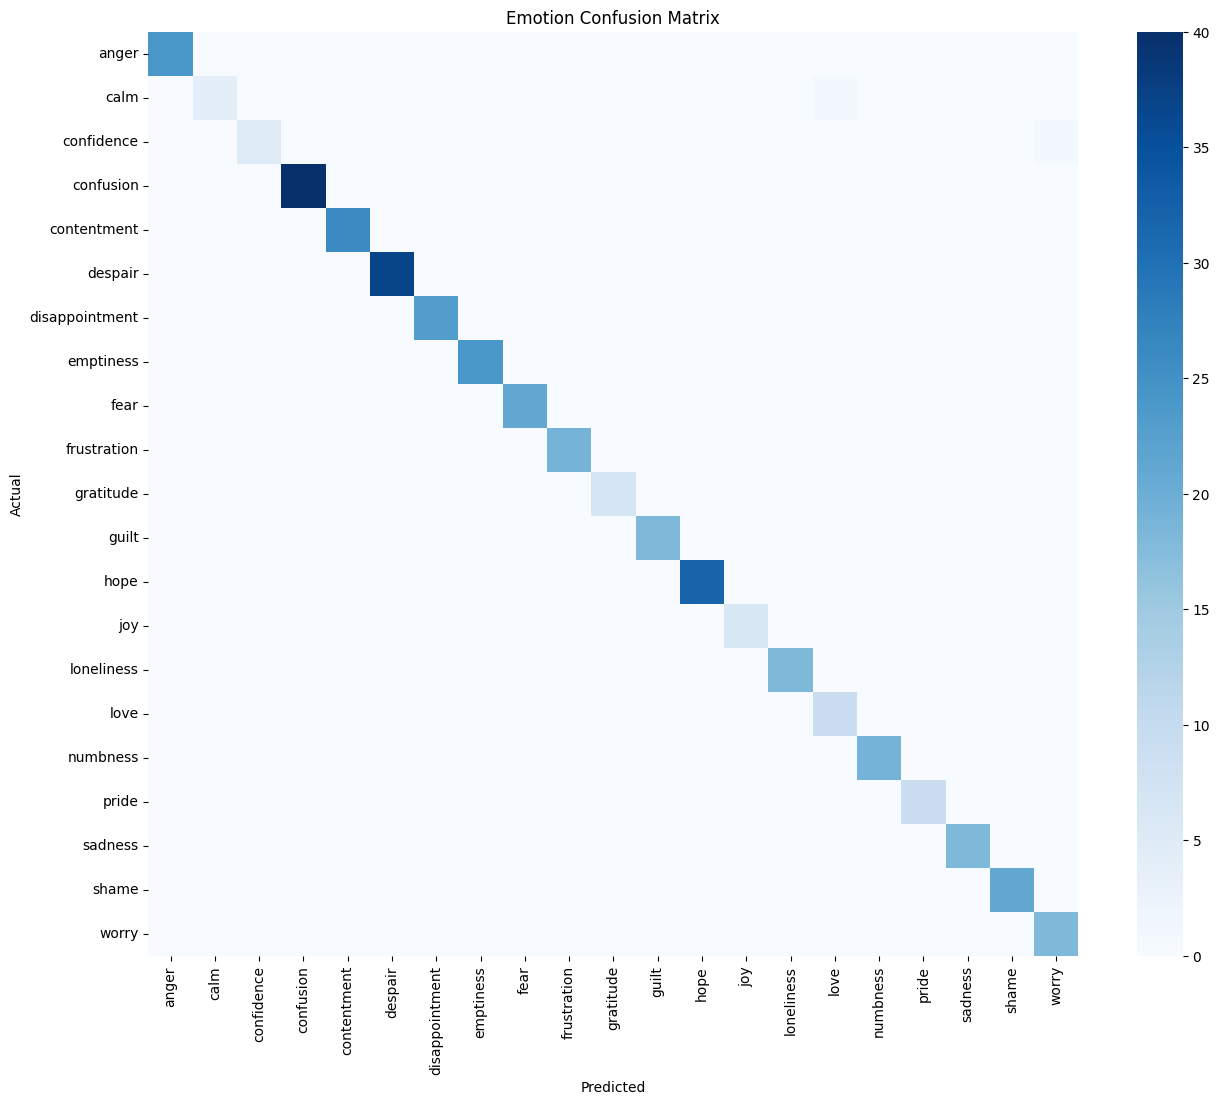

In [15]:
cm = confusion_matrix(
    y_test,
    y_pred,
    labels=model.classes_
)

plt.figure(figsize=(15,12))

sns.heatmap(
    cm,
    cmap="Blues",
    xticklabels=model.classes_,
    yticklabels=model.classes_
)

plt.title("Emotion Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

#### Feature Importance

In [16]:
feature_names = vectorizer.get_feature_names_out()

for i, emotion in enumerate(model.classes_):

    top_idx = model.coef_[i].argsort()[-15:]

    print("\nEMOTION:", emotion)

    print(
        [feature_names[j]
         for j in top_idx]
    )


EMOTION: anger
['anger destroying', 'selfdirected', 'selfdirected anger', 'destroying inside', 'letting', 'letting thing', 'im furious', 'also', 'furious', 'im angry', 'anger injustice', 'hate', 'injustice', 'angry', 'anger']

EMOTION: calm
['muscle', 'feel relaxed', 'relaxed calmness', 'relaxed', 'time body', 'yoga', 'yoga first', 'muscle spread', 'calmness muscle', 'body feel', 'spread mind', 'spread', 'calmness', 'sat', 'calm']

EMOTION: confidence
['boundary', 'healthy', 'healthy boundary', 'say without', 'confidence worth', 'growing every', 'guilty confidence', 'worth growing', 'feeling guilty', 'learned say', 'worth', 'growing', 'feel confident', 'confident', 'confidence']

EMOTION: confusion
['concerning', 'powerless', 'class work', 'schedule packed', 'work dont', 'packed', 'packed class', 'sure', 'im sure', 'academic', 'current', 'yet', 'adequate', 'situation', 'neither']

EMOTION: contentment
['coexist peacefully', 'least coexist', 'getting along', 'peacefully', 'coexist', 'r

#### Error Analysis

In [17]:
errors = pd.DataFrame({
    "text": X_test,
    "actual": y_test,
    "predicted": y_pred
})

errors[
    errors["actual"] != errors["predicted"]
].head(20)

,text,actual,predicted
514,pitched business idea investor didnt fund gave...,confidence,worry
1974,watched wave beach hour rhythm ocean brought d...,calm,love


#### Save Model

In [26]:
joblib.dump(
    model,
    "C:\\Users\\yasmine\\Documents\\neps\\neps-ml-ai\\models\\emotion_detection_model.pkl"
)

joblib.dump(
    vectorizer,
    "C:\\Users\\yasmine\\Documents\\neps\\neps-ml-ai\\models\\emotion_detection_vectorizer.pkl"
)

['C:\\Users\\yasmine\\Documents\\neps\\neps-ml-ai\\models\\emotion_detection_vectorizer.pkl']

#### Save Pipeline

In [27]:
from sklearn.pipeline import Pipeline

emotion_pipeline = Pipeline([

    (
        "tfidf",

        TfidfVectorizer(
            max_features=15000,
            ngram_range=(1,2)
        )
    ),

    (
        "classifier",

        LogisticRegression(
            max_iter=1000,
            class_weight="balanced"
        )
    )
])

emotion_pipeline.fit(
    df["clean_text"],
    df["emotional_label"]
)

joblib.dump(
    emotion_pipeline,
    "C:\\Users\\yasmine\\Documents\\neps\\neps-ml-ai\\models\\emotion_detection_pipeline.pkl"
)

['C:\\Users\\yasmine\\Documents\\neps\\neps-ml-ai\\models\\emotion_detection_pipeline.pkl']